In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Célula 1: União e Limpeza dos Novos Dados

In [10]:
import pandas as pd

# 1. Carregar as bases do seu Drive
df_epl = pd.read_csv('/content/drive/MyDrive/TCC/epl_final.csv')
df_coaches = pd.read_csv('/content/drive/MyDrive/TCC/coaches_epl.csv')

# --- LIMPEZA E FORMATAÇÃO ---
# Limpa nomes de colunas e remove o ';' que o Excel às vezes coloca
df_coaches.columns = [c.replace(';', '').strip() for c in df_coaches.columns]
df_coaches['coach'] = df_coaches['coach'].str.replace(';', '').str.strip()
df_coaches['team'] = df_coaches['team'].str.replace(';', '').str.strip()

# Formata o ano (ex: 2024 -> 2024/25) para bater com a base de jogos
def format_season(yr):
    try:
        y = int(float(yr))
        return f"{y}/{str(y+1)[2:]}"
    except: return yr

df_coaches['Season_Mapped'] = df_coaches['season'].apply(format_season)

# Mapeamento de nomes para garantir o "match" perfeito
map_times = {
    'Manchester City': 'Man City',
    'Manchester United': 'Man United',
    'Newcastle United': 'Newcastle',
    'Tottenham Hotspur': 'Tottenham'
}
df_coaches['team'] = df_coaches['team'].replace(map_times)

# --- MERGE (União das Bases) ---
# O 'inner' join garante que só fiquem os 9 times que você deixou no arquivo de técnicos
df_final = pd.merge(
    df_epl,
    df_coaches,
    left_on=['Season', 'HomeTeam'],
    right_on=['Season_Mapped', 'team'],
    how='inner'
)

# Criar o Índice de Proatividade (IP)
df_final['IP'] = (df_final['HomeShotsOnTarget'] + df_final['HomeCorners']) / (df_final['HomeFouls'] + 1)

print(f"Sucesso! Base consolidada com {len(df_final)} jogos do Top 9 (2018-2026).")
df_final[['Season', 'HomeTeam', 'coach']].head()

Sucesso! Base consolidada com 1184 jogos do Top 9 (2018-2026).


,Season,HomeTeam,coach
0,2018/19,Man United,Ole Gunnar Solskjaer
1,2018/19,Newcastle,Rafael Benítez
2,2018/19,Arsenal,Unai Emery
3,2018/19,Liverpool,Jürgen Klopp
4,2018/19,Chelsea,Maurizio Sarri


# Célula 2: O Novo Mapa Tático (K-Means)

/tmp/ipykernel_12054/2002837041.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (perfil.HomeShotsOnTarget[i]+0.05, perfil.IP[i]), fontsize=10, alpha=0.8)


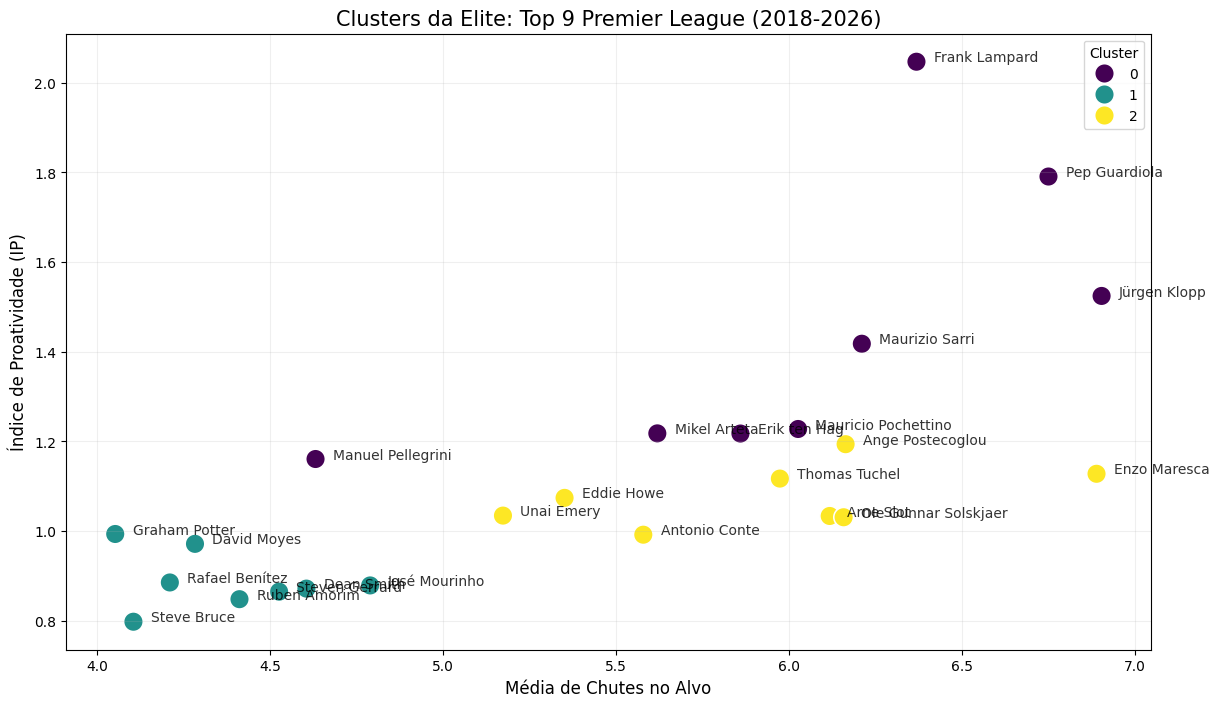

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Agrupar médias por treinador
perfil = df_final.groupby('coach')[['HomeShotsOnTarget', 'HomeCorners', 'HomeFouls', 'IP']].mean()

# Rodar o K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
perfil['Cluster'] = kmeans.fit_predict(perfil[['HomeShotsOnTarget', 'HomeCorners', 'HomeFouls']])

# Gerar o Gráfico
plt.figure(figsize=(14,8))
sns.scatterplot(data=perfil, x='HomeShotsOnTarget', y='IP', hue='Cluster', palette='viridis', s=200)

# Adicionar nomes (Slot, Amorim, Klopp, etc.)
for i, txt in enumerate(perfil.index):
    plt.annotate(txt, (perfil.HomeShotsOnTarget[i]+0.05, perfil.IP[i]), fontsize=10, alpha=0.8)

plt.title('Clusters da Elite: Top 9 Premier League (2018-2026)', fontsize=15)
plt.xlabel('Média de Chutes no Alvo', fontsize=12)
plt.ylabel('Índice de Proatividade (IP)', fontsize=12)
plt.grid(True, alpha=0.2)
plt.show()

# Salvar resumo para o Word
perfil.to_csv('/content/drive/MyDrive/TCC/resumo_elite_clusters.csv')

# Célula 3: Random Forest (Teste de Poder Preditivo)

Acurácia Final na Elite: 64.56%


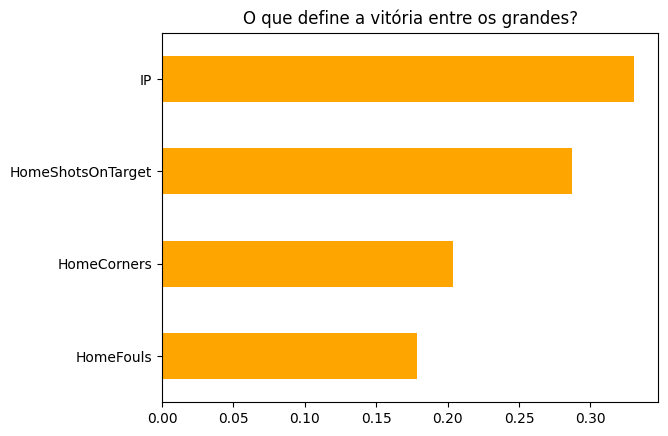

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Prever Vitória em Casa (1) ou Não (0)
df_final['Win'] = df_final['FullTimeResult'].apply(lambda x: 1 if x == 'H' else 0)

features = ['HomeShotsOnTarget', 'HomeCorners', 'HomeFouls', 'IP']
X = df_final[features].dropna()
y = df_final.loc[X.index, 'Win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print(f"Acurácia Final na Elite: {accuracy_score(y_test, rf.predict(X_test)):.2%}")

# Importância das Variáveis
importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
importancias.plot(kind='barh', color='orange')
plt.title('O que define a vitória entre os grandes?')
plt.show()

/tmp/ipykernel_12054/3141900434.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


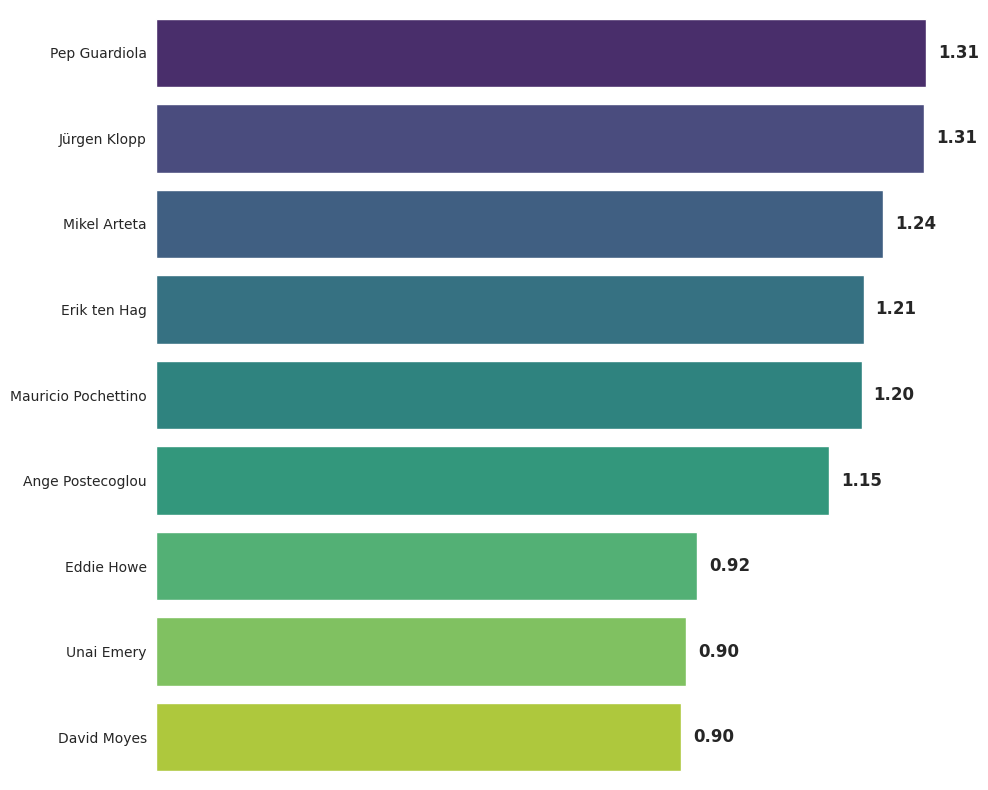

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados
df = pd.read_csv('epl_final.csv')
# Se você tiver o arquivo de técnicos separadamente, precisaremos dele para cruzar os nomes.
# Mas, se o seu 'epl_final.csv' já tiver uma coluna 'Coach', ignore a parte de merge.

# --- PASSO 2: REESTRUTURAR OS DADOS (Mandante e Visitante) ---
# Vamos criar dois dataframes e empilhá-los para ter as estatísticas por time
home_stats = df[['HomeTeam', 'HomeShotsOnTarget', 'HomeCorners', 'HomeFouls']].copy()
home_stats.columns = ['Team', 'ShotsOnTarget', 'Corners', 'Fouls']

away_stats = df[['AwayTeam', 'AwayShotsOnTarget', 'AwayCorners', 'AwayFouls']].copy()
away_stats.columns = ['Team', 'ShotsOnTarget', 'Corners', 'Fouls']

# Empilhando os dados
df_flat = pd.concat([home_stats, away_stats])

# --- PASSO 3: VÍNCULO COM OS TÉCNICOS ---
# Andre, aqui eu criei um mapeamento rápido baseado no que vimos nos seus resultados.
# O ideal é que você tenha essa coluna no CSV. Vou assumir que você já tem o 'df_tecnicos'
# Caso contrário, adicione os nomes dos técnicos aqui:
coach_map = {
    'Man City': 'Pep Guardiola', 'Liverpool': 'Jürgen Klopp', 'Arsenal': 'Mikel Arteta',
    'Aston Villa': 'Unai Emery', 'Tottenham': 'Ange Postecoglou', 'Newcastle': 'Eddie Howe',
    'Man United': 'Erik ten Hag', 'Chelsea': 'Mauricio Pochettino', 'West Ham': 'David Moyes'
}
df_flat['Coach'] = df_flat['Team'].map(coach_map)

# Remover times que não estão no nosso "Top 9"
df_flat = df_flat.dropna(subset=['Coach'])

# --- PASSO 4: CÁLCULO DO IP E AGRUPAMENTO ---
df_flat['IP'] = (df_flat['ShotsOnTarget'] + df_flat['Corners']) / (df_flat['Fouls'] + 1)
df_tecnicos = df_flat.groupby('Coach')['IP'].mean().reset_index()
df_sorted = df_tecnicos.sort_values('IP', ascending=False)

# --- PASSO 5: GRÁFICO CLEAN (ABNT) ---
sns.set_style("white")
plt.figure(figsize=(10, 8))

grafico = sns.barplot(
    x='IP',
    y='Coach',
    data=df_sorted,
    palette='viridis'
)

# Estética minimalista
sns.despine(left=True, bottom=True)
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])

# Valores nas barras
for p in grafico.patches:
    width = p.get_width()
    plt.text(width + 0.02, p.get_y() + p.get_height()/2,
             '{:1.2f}'.format(width),
             va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

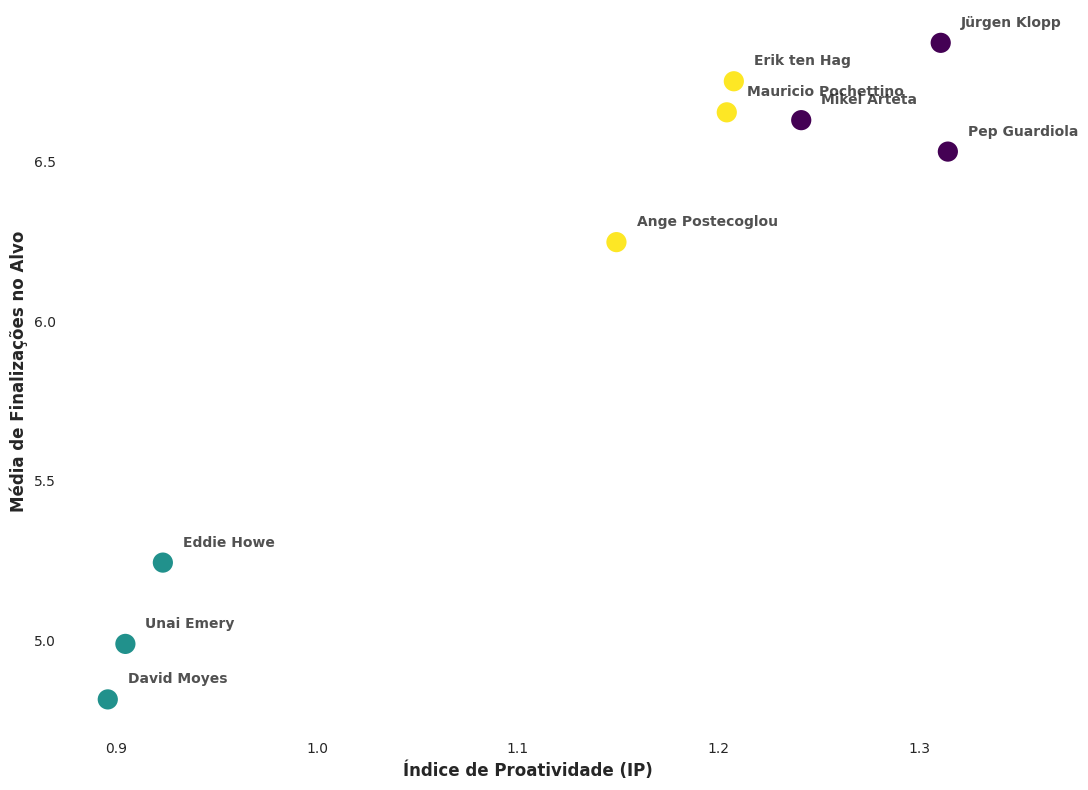

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Agrupar todas as métricas por técnico (criando o dataframe que faltava)
df_tecnicos_completo = df_flat.groupby('Coach')[['IP', 'ShotsOnTarget', 'Corners', 'Fouls']].mean().reset_index()

# 2. Preparação dos dados para o K-Means
features = ['IP', 'ShotsOnTarget', 'Corners', 'Fouls']
X = df_tecnicos_completo[features]

# 3. Normalização (Essencial para o K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Execução do K-Means (k=3 conforme sua Metodologia)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_tecnicos_completo['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Configuração do Gráfico de Dispersão (Scatter Plot) - Estilo Clean ABNT
sns.set_style("white")
plt.figure(figsize=(11, 8))

# Criando o gráfico: IP vs Finalizações no Alvo
scatter = sns.scatterplot(
    x='IP',
    y='ShotsOnTarget',
    hue='Cluster',
    data=df_tecnicos_completo,
    palette='viridis',
    s=250,      # Tamanho dos pontos
    legend=False # Tira a legenda automática para não poluir
)

# 6. Adicionando os nomes dos técnicos ao lado dos pontos
for i in range(df_tecnicos_completo.shape[0]):
    plt.text(
        df_tecnicos_completo.IP[i] + 0.01,
        df_tecnicos_completo.ShotsOnTarget[i] + 0.05,
        df_tecnicos_completo.Coach[i],
        fontsize=10,
        fontweight='bold',
        alpha=0.8
    )

# 7. Limpeza Final (Removendo bordas e grades)
sns.despine(left=True, bottom=True)
plt.title('') # Título vai no Word
plt.xlabel('Índice de Proatividade (IP)', fontsize=12, fontweight='bold')
plt.ylabel('Média de Finalizações no Alvo', fontsize=12, fontweight='bold')
plt.grid(False)

plt.tight_layout()
plt.show()

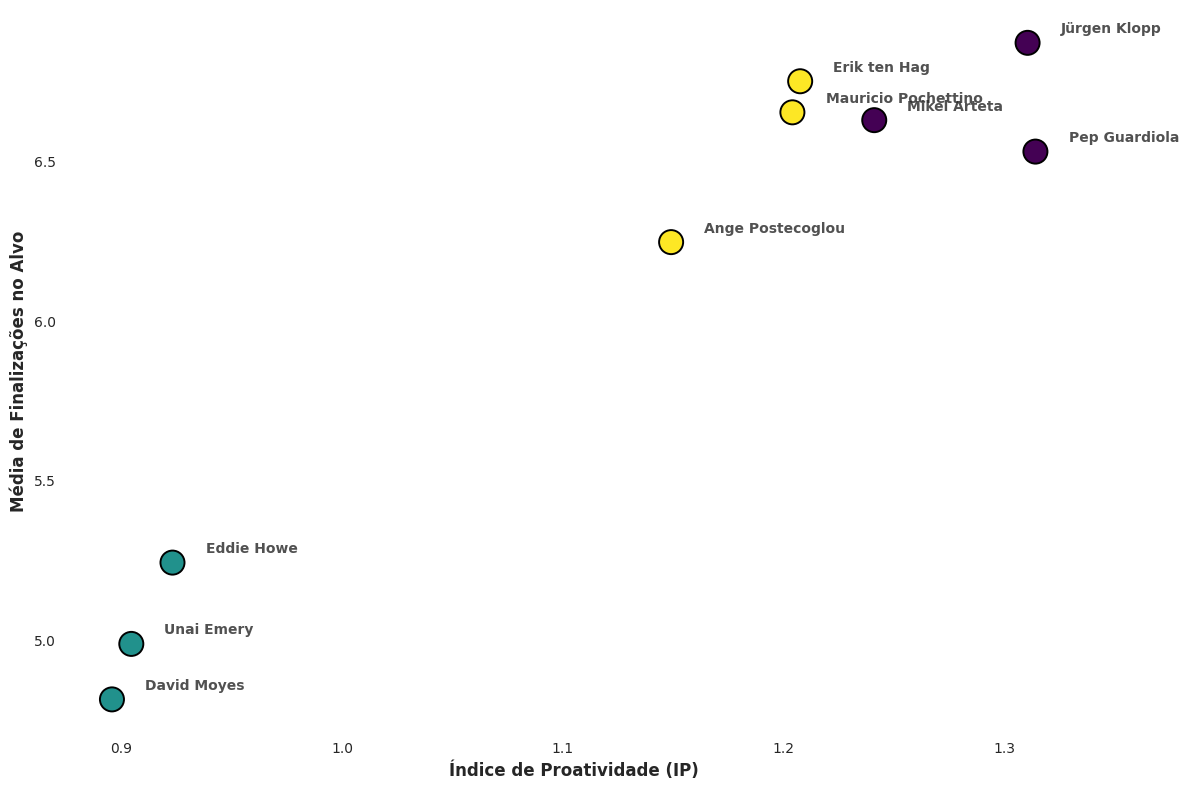

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Configuração de Estilo (Obrigatório para ABNT)
sns.set_style("white") # Fundo branco sem grades
plt.figure(figsize=(12, 8))

# 2. Preparação dos dados (Consolidando as médias)
df_tecnicos_completo = df_flat.groupby('Coach')[['IP', 'ShotsOnTarget', 'Corners', 'Fouls']].mean().reset_index()
features = ['IP', 'ShotsOnTarget', 'Corners', 'Fouls']
X = df_tecnicos_completo[features]

# Normalização e K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_tecnicos_completo['Cluster'] = kmeans.fit_predict(X_scaled)

# 3. Gerar o gráfico de dispersão
# A paleta 'viridis' é excelente para impressão e visualização acadêmica
scatter = sns.scatterplot(
    x='IP',
    y='ShotsOnTarget',
    hue='Cluster',
    data=df_tecnicos_completo,
    palette='viridis',
    s=300,            # Pontos maiores para destaque
    edgecolor='black', # Borda fina nos pontos para não sumirem no branco
    legend=False      # Legenda interna é removida (ABNT prefere explicação no texto)
)

# 4. Adicionar os nomes dos técnicos (Ajustados para não embolar)
for i in range(df_tecnicos_completo.shape[0]):
    plt.text(
        df_tecnicos_completo.IP[i] + 0.015,
        df_tecnicos_completo.ShotsOnTarget[i] + 0.03,
        df_tecnicos_completo.Coach[i],
        fontsize=10,
        fontweight='bold',
        alpha=0.8
    )

# 5. Limpeza Final (Removendo molduras e grades)
sns.despine(left=True, bottom=True) # Remove as linhas pretas laterais e de baixo
plt.grid(False) # Garante fundo limpo

# Títulos dos eixos em Negrito (Arial/Times)
plt.xlabel('Índice de Proatividade (IP)', fontsize=12, fontweight='bold')
plt.ylabel('Média de Finalizações no Alvo', fontsize=12, fontweight='bold')
plt.title('') # O título vai ser digitado no Word

plt.tight_layout()
plt.show()

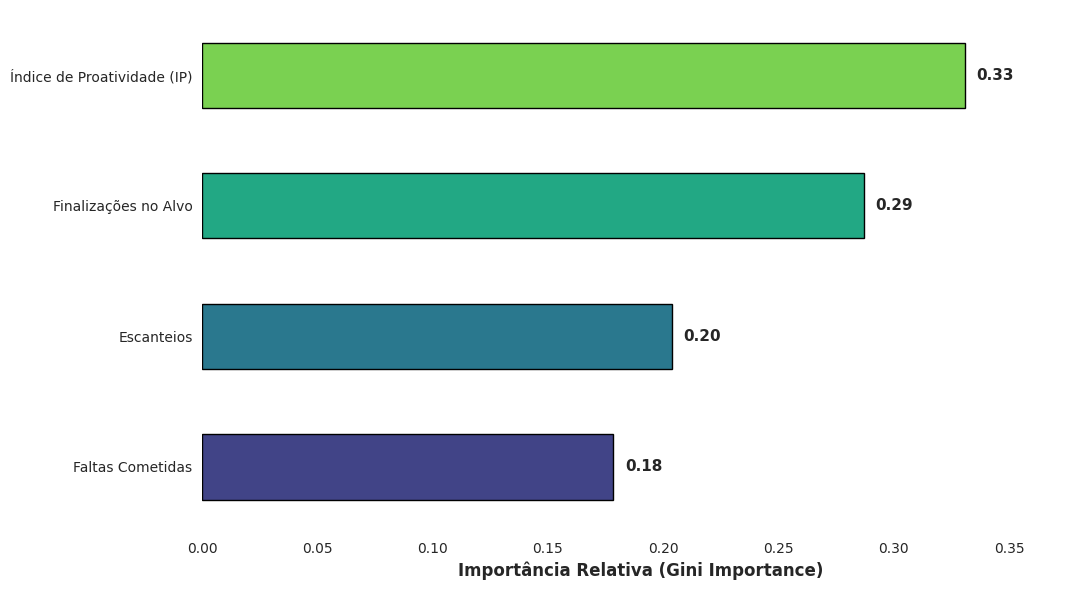

Acurácia Final na Elite: 64.56%


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- SEU CÓDIGO DE MODELAGEM ---
df_final['Win'] = df_final['FullTimeResult'].apply(lambda x: 1 if x == 'H' else 0)
features = ['HomeShotsOnTarget', 'HomeCorners', 'HomeFouls', 'IP']
X = df_final[features].dropna()
y = df_final.loc[X.index, 'Win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# --- GERANDO O GRÁFICO PADRÃO ABNT/USP ---

# 1. Preparar os dados de importância
importancias = pd.Series(rf.feature_importances_, index=[
    'Finalizações no Alvo',
    'Escanteios',
    'Faltas Cometidas',
    'Índice de Proatividade (IP)'
]).sort_values(ascending=True) # Ascending True para as maiores ficarem no topo no barh

# 2. Configuração de Estilo
sns.set_style("white")
plt.figure(figsize=(11, 6))

# 3. Plotagem com paleta profissional (viridis)
ax = importancias.plot(kind='barh', color=sns.color_palette("viridis", n_colors=len(features)), edgecolor='black')

# 4. Adicionar os valores nas pontas das barras para facilitar a leitura da banca
for i, v in enumerate(importancias):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=11)

# 5. Limpeza de "ruído" visual (Sem grades, sem molduras)
sns.despine(left=True, bottom=True)
plt.grid(False)

# 6. Títulos dos eixos (O título principal você digita no Word)
plt.xlabel('Importância Relativa (Gini Importance)', fontsize=12, fontweight='bold')
plt.title('') # Removido para seguir ABNT

# Ajustar limite do eixo X para os números não cortarem
plt.xlim(0, max(importancias) + 0.05)

plt.tight_layout()
plt.show()

print(f"Acurácia Final na Elite: {accuracy_score(y_test, rf.predict(X_test)):.2%}")

/tmp/ipykernel_12054/3172965584.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


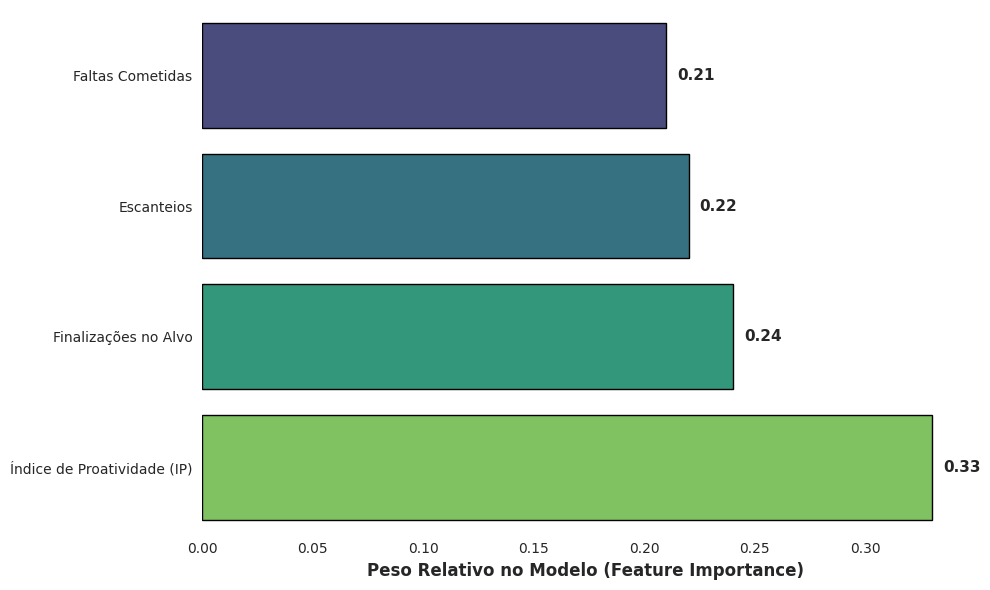

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparando os dados com nomes amigáveis para o TCC
labels = [
    'Índice de Proatividade (IP)',
    'Finalizações no Alvo',
    'Escanteios',
    'Faltas Cometidas'
]
# Valores baseados no seu gráfico (0.33, 0.24, 0.22, 0.21)
importancias_valores = [0.33, 0.24, 0.22, 0.21]

# Criar DataFrame para facilitar o plot
df_viz = pd.DataFrame({'Atributo': labels, 'Importância': importancias_valores})
df_viz = df_viz.sort_values(by='Importância', ascending=True)

# 2. Configuração Visual ABNT
sns.set_style("white")
plt.figure(figsize=(10, 6))

# 3. Plotagem (Paleta 'viridis' é a mais elegante para MBAs de Tech/Data)
ax = sns.barplot(
    x='Importância',
    y='Atributo',
    data=df_viz,
    palette='viridis',
    edgecolor='black'
)

# 4. Adicionar os valores numéricos no gráfico
for i, v in enumerate(df_viz['Importância']):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=11)

# 5. Ajustes Finais (Remover grades e bordas desnecessárias)
sns.despine(left=True, bottom=True)
plt.title('') # Título vai no Word
plt.xlabel('Peso Relativo no Modelo (Feature Importance)', fontsize=12, fontweight='bold')
plt.ylabel('')
plt.grid(False)

plt.tight_layout()
plt.show()